In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")
# Setting visualization styles
sns.set_theme(style="whitegrid")
#%matplotlib inline

In [2]:
df=pd.read_csv("Zomato data new.csv")

**Phase 1**

In [3]:
df.info()
df.shape
df.head().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211944 entries, 0 to 211943
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   res_id                211944 non-null  int64  
 1   name                  211944 non-null  object 
 2   establishment         211944 non-null  object 
 3   address               211810 non-null  object 
 4   city                  211944 non-null  object 
 5   locality              211944 non-null  object 
 6   latitude              211944 non-null  float64
 7   longitude             211944 non-null  float64
 8   zipcode               48757 non-null   object 
 9   cuisines              210553 non-null  object 
 10  timings               208070 non-null  object 
 11  average_cost_for_two  211944 non-null  int64  
 12  price_range           211944 non-null  int64  
 13  currency              211944 non-null  object 
 14  highlights            211944 non-null  object 
 15  

,0,1,2,3,4
res_id,3400299,3400005,3401013,3400290,3401744
name,Bikanervala,Mama Chicken Mama Franky House,Bhagat Halwai,Bhagat Halwai,The Salt Cafe Kitchen & Bar
establishment,['Quick Bites'],['Quick Bites'],['Quick Bites'],['Quick Bites'],['Casual Dining']
address,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...","Main Market, Sadar Bazaar, Agra Cantt, Agra","62/1, Near Easy Day, West Shivaji Nagar, Goalp...","Near Anjana Cinema, Nehru Nagar, Civil Lines, ...","1C,3rd Floor, Fatehabad Road, Tajganj, Agra"
city,Agra,Agra,Agra,Agra,Agra
locality,Khandari,Agra Cantt,Shahganj,Civil Lines,Tajganj
latitude,27.21145,27.160569,27.182938,27.205668,27.157709
longitude,78.002381,78.011583,77.979684,78.004799,78.052421
zipcode,NaN,282001,282010,282002,NaN
cuisines,"North Indian, South Indian, Mithai, Street Foo...","North Indian, Mughlai, Rolls, Chinese, Fast Fo...","Fast Food, Mithai","Desserts, Bakery, Fast Food, South Indian","North Indian, Continental, Italian"


**Handling Missing Values**

In [4]:
df.isnull().sum()

res_id                       0
name                         0
establishment                0
address                    134
city                         0
locality                     0
latitude                     0
longitude                    0
zipcode                 163187
cuisines                  1391
timings                   3874
average_cost_for_two         0
price_range                  0
currency                     0
highlights                   0
aggregate_rating             0
rating_text                  0
votes                        0
photo_count                  0
delivery                     0
takeaway                     0
dtype: int64

In [5]:
#Drop the zipcode column (too many missing values)
df.drop(columns=['zipcode'], inplace=True)


#Filling missing timings and cuisines with placeholders
df['timings'] = df['timings'].fillna('Not Available')
df['cuisines'] = df['cuisines'].fillna('Other')

# Droping rows where address is missing (very few rows)
df.dropna(subset=['address'], inplace=True)

In [6]:
df.isnull().sum()

res_id                  0
name                    0
establishment           0
address                 0
city                    0
locality                0
latitude                0
longitude               0
cuisines                0
timings                 0
average_cost_for_two    0
price_range             0
currency                0
highlights              0
aggregate_rating        0
rating_text             0
votes                   0
photo_count             0
delivery                0
takeaway                0
dtype: int64

**Handling Duplicate Entries**

In [7]:
df.duplicated().sum()

np.int64(151417)

In [8]:
# Mark all rows that are duplicates
is_duplicate = df.duplicated(keep=False)

# Filter the dataframe first to only include duplicates
repeats_only = df[is_duplicate].copy()

# Now group the much smaller subset
repeats_only = repeats_only.groupby(repeats_only.columns.tolist(), observed=True).size().reset_index(name='Duplicate_Count')


In [9]:
# Droping duplicates and keep the first occurrence
df.drop_duplicates(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60393 entries, 0 to 211942
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   res_id                60393 non-null  int64  
 1   name                  60393 non-null  object 
 2   establishment         60393 non-null  object 
 3   address               60393 non-null  object 
 4   city                  60393 non-null  object 
 5   locality              60393 non-null  object 
 6   latitude              60393 non-null  float64
 7   longitude             60393 non-null  float64
 8   cuisines              60393 non-null  object 
 9   timings               60393 non-null  object 
 10  average_cost_for_two  60393 non-null  int64  
 11  price_range           60393 non-null  int64  
 12  currency              60393 non-null  object 
 13  highlights            60393 non-null  object 
 14  aggregate_rating      60393 non-null  float64
 15  rating_text           6

In [11]:
#Rechecking Duplicated Rows
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")

Total duplicate rows: 0


**Checking For Outliers**

       average_cost_for_two         votes  aggregate_rating
count          60393.000000  60393.000000      60393.000000
mean             538.433163    261.655689          3.033542
std              593.876838    728.412867          1.440200
min                0.000000    -18.000000          0.000000
25%              200.000000      7.000000          2.900000
50%              400.000000     42.000000          3.500000
75%              600.000000    207.000000          4.000000
max            30000.000000  42539.000000          4.900000


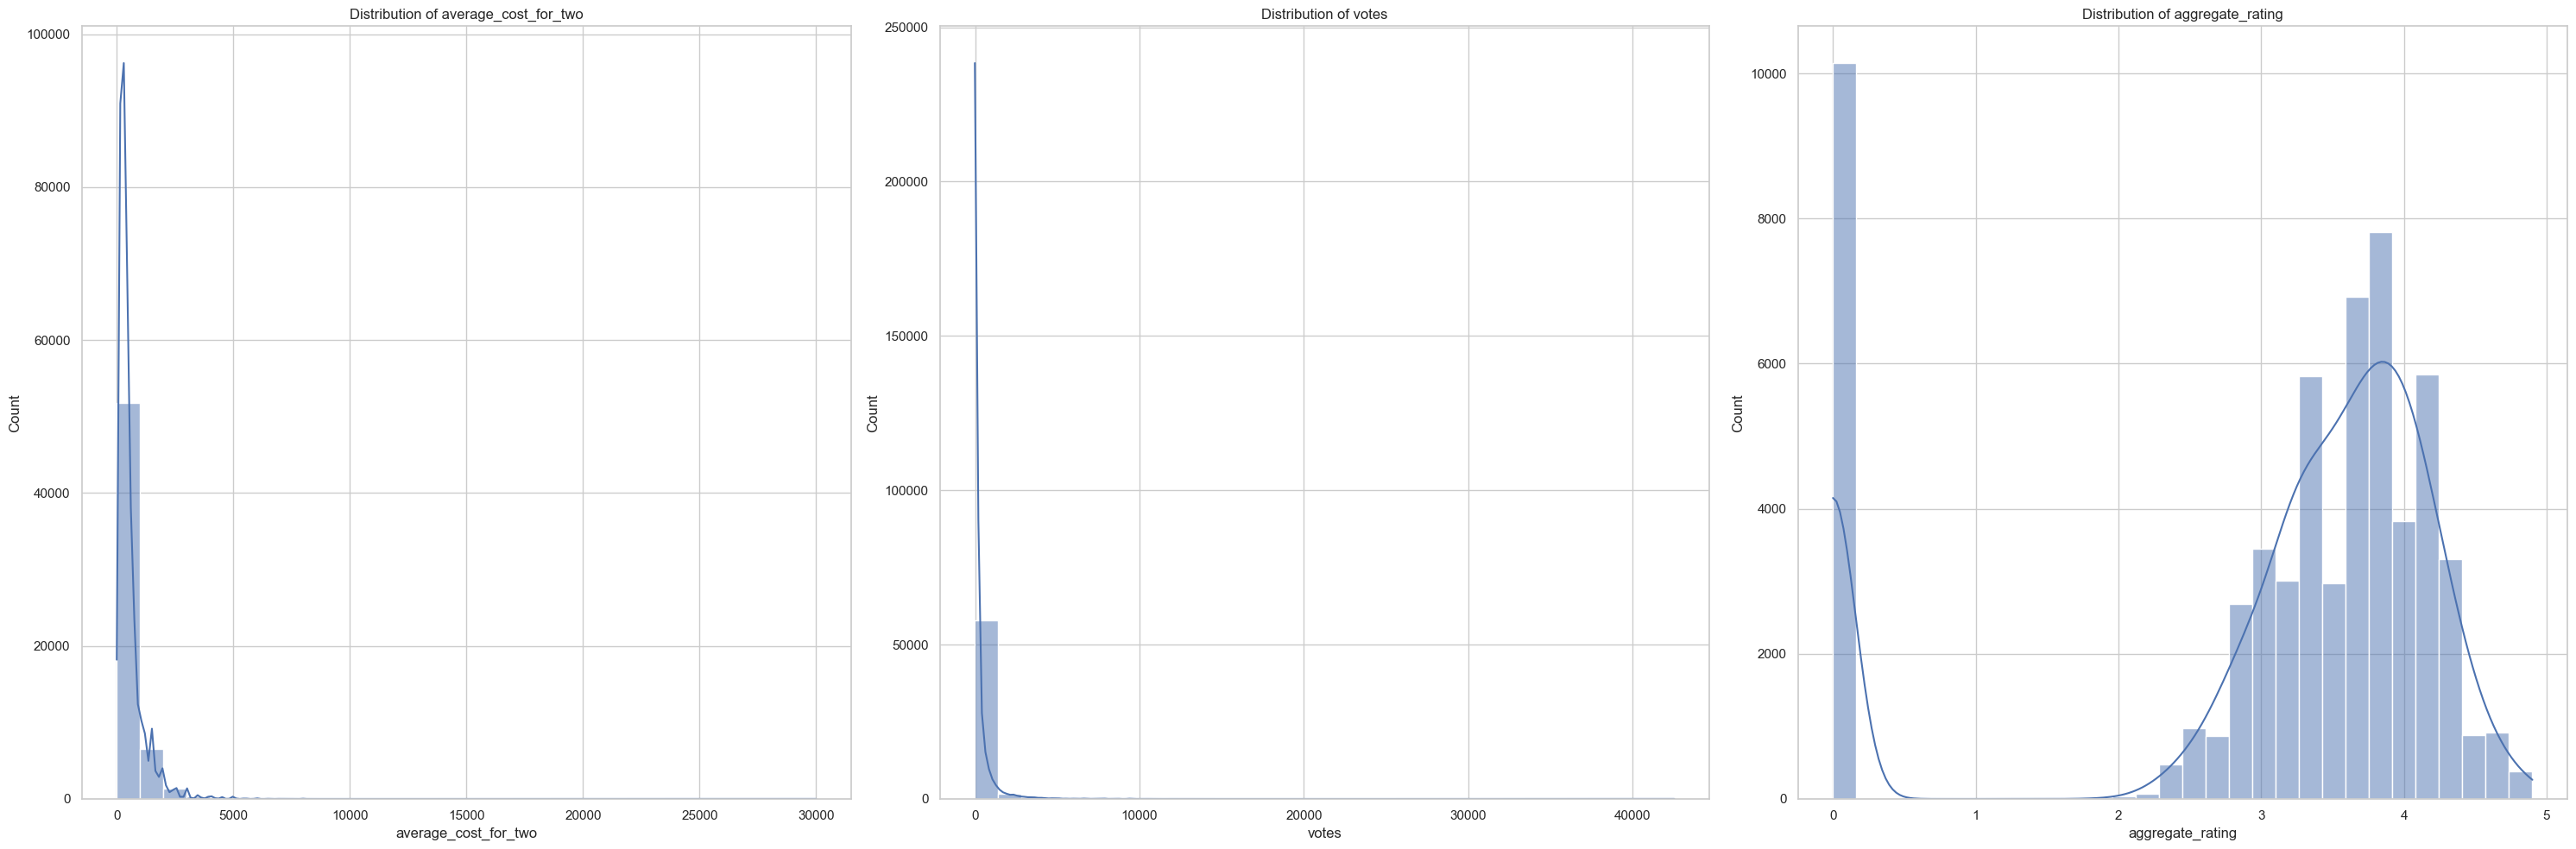

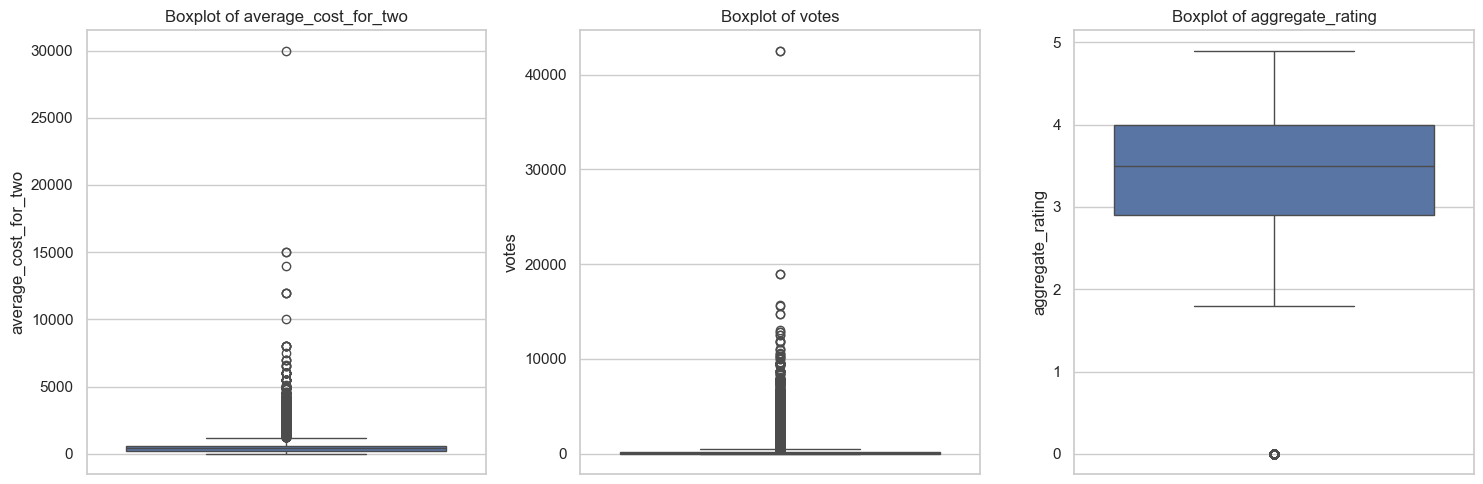

In [12]:
# Select the primary numeric columns for distribution and outlier analysis
numeric_cols = ['average_cost_for_two', 'votes', 'aggregate_rating']

# Display basic statistics to get an idea of the distribution and potential outliers
stats = df[numeric_cols].describe()
print(stats)

# Set up the visualization
plt.figure(figsize=(30, 10))

# Plotting distribution (Histograms)
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

# Plotting outliers (Boxplots)
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.savefig('outliers.png')
plt.show()

**Core Exploratory Data Analysis**

**Distribution of Restaurant Rating**

**Phase 2**

Total Restaurants: 60393
Number of 0.0 Ratings: 10144
Percentage of 0.0 Ratings: 16.80%


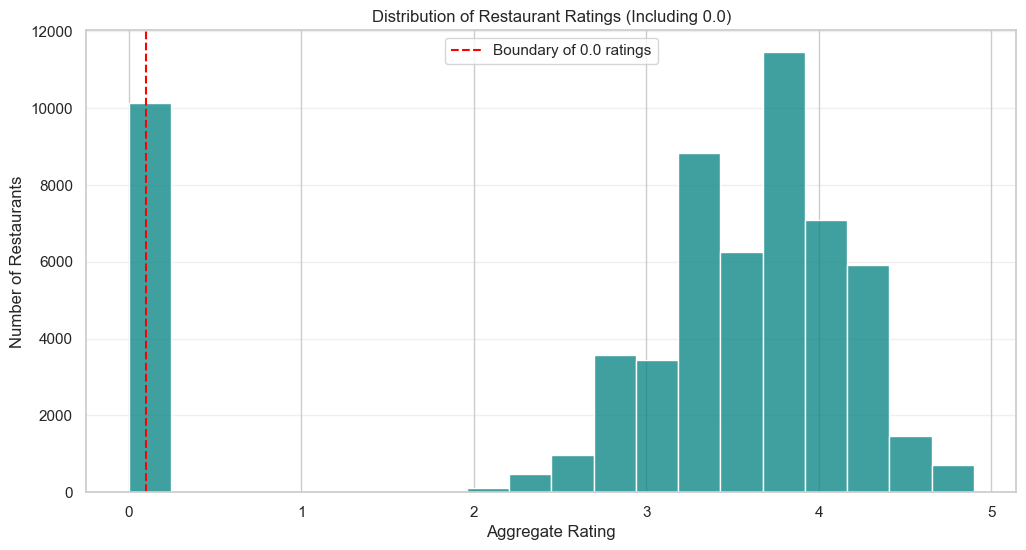

In [13]:
# Aggregate Rating Analysis
# Total counts for each rating to see the frequency of 0.0
rating_counts = df['aggregate_rating'].value_counts().sort_index()

# 2. Separate data into "Rated" and "Unrated (0.0)"
unrated_count = (df['aggregate_rating'] == 0).sum()
total_count = len(df)
unrated_percentage = (unrated_count / total_count) * 100

# 3. Visualizing the distribution including 0.0
plt.figure(figsize=(12, 6))
sns.histplot(df['aggregate_rating'], bins=20, kde=False, color='teal')
plt.axvline(0.1, color='red', linestyle='--', label='Boundary of 0.0 ratings')
plt.title('Distribution of Restaurant Ratings (Including 0.0)')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('q5_rating_distribution.png')

# 4. Summary of findings
print(f"Total Restaurants: {total_count}")
print(f"Number of 0.0 Ratings: {unrated_count}")
print(f"Percentage of 0.0 Ratings: {unrated_percentage:.2f}%")

**1.Rating Distribution Summary**

The majority of restaurants that have received reviews are clustered between 3.0 and 4.5, indicating a generally positive sentiment or a tendency for users to rate mid-to-high.

Total Restaurants Analyzed: 60393

Most Frequent Rating Range: 3.7 to 4.2

The 0.0 Spike: There is a significant anomaly with 10144 restaurants holding a rating of exactly 0.0.

**2.What do the 0.0 ratings signify?**

A $0.0$ rating on Zomato typically does not mean the restaurant received a zero-star review. Instead, it signifies:

"Not Rated": The restaurant is likely new to the platform and hasn't received enough reviews to calculate an aggregate score.

Inactive/Placeholder: The listing might be a placeholder where no user interaction has occurred yet.

**Cities with highest number of restaurants on Zomato**

Top 10 Cities and Restaurant Counts:
        City  Restaurant Count
0    Chennai              2612
1     Mumbai              2538
2  Bangalore              2365
3       Pune              1911
4  New Delhi              1847
5     Jaipur              1456
6    Kolkata              1413
7  Ahmedabad              1329
8    Lucknow              1290
9        Goa              1169


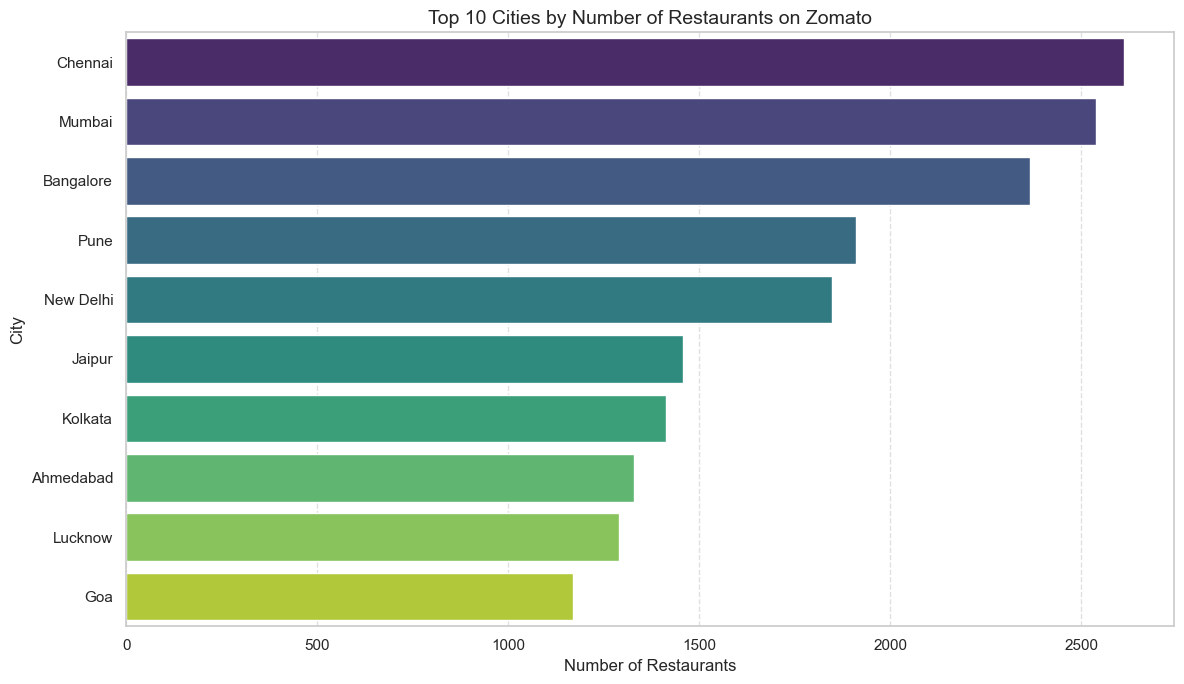

In [14]:
# Cities with the highest number of restaurants
top_cities = df['city'].value_counts().head(10).reset_index()
top_cities.columns = ['City', 'Restaurant Count']

# Visualization
plt.figure(figsize=(12, 7))
sns.barplot(data=top_cities, x='Restaurant Count', y='City', palette='viridis')
plt.title('Top 10 Cities by Number of Restaurants on Zomato', fontsize=14)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('q6_top_cities.png')

print("Top 10 Cities and Restaurant Counts:")
print(top_cities)

**Interpretation**

here are the cities with the most restaurant listings:


Chennai leads the pack by a significant margin with 2612 listings.

Mumbai follows in second place with 2538 restaurants.



Bangalore holds the third spot with 2365 listings.

**Top 10 most common cuisines offered**

        Cuisine  Count
0  North Indian  21258
1       Chinese  14138
2     Fast Food  13191
3      Desserts   7753
4     Beverages   7486
5  South Indian   7083
6   Continental   5774
7        Bakery   5063
8          Cafe   4804
9       Italian   4293


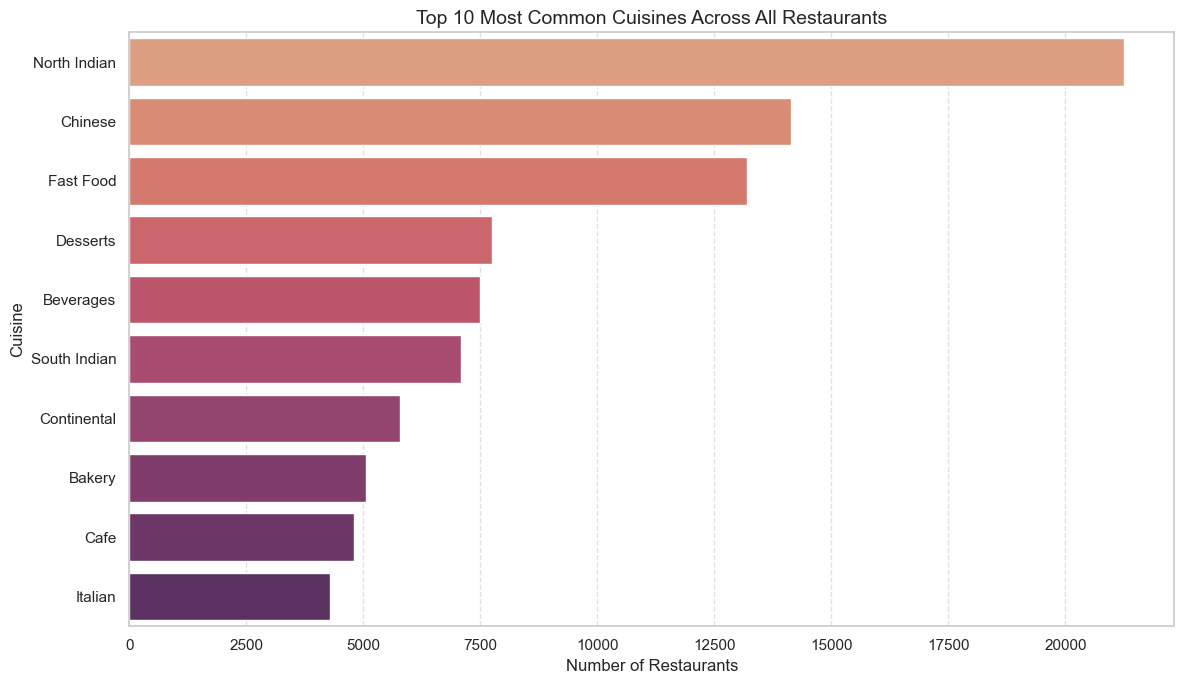

In [15]:
# We need to split the cuisines since many restaurants offer multiple
cuisine_series = df['cuisines'].dropna().str.split(', ')
all_cuisines = [cuisine.strip() for sublist in cuisine_series for cuisine in sublist]

# Create a DataFrame for the counts
cuisine_counts = pd.Series(all_cuisines).value_counts().head(10).reset_index()
cuisine_counts.columns = ['Cuisine', 'Count']

# Visualization
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=cuisine_counts,x='Count',y='Cuisine',hue='Cuisine',palette='flare')

# Fix the legend issue (FutureWarning)
#if ax.legend_:
#    ax.legend_.remove()

plt.title('Top 10 Most Common Cuisines Across All Restaurants', fontsize=14)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('q7_cuisines.png')

print(cuisine_counts)

**Interpretation**

After analyzing the cuisines column (and accounting for restaurants that serve multiple cuisines by splitting comma-separated entries), here are the most prevalent food types in the dataset:

North Indian is the dominant cuisine, appearing in 21258 listings.

Chinese hold the second place with 14138 listing

Fast Food holds the third place with 13191 listing

**Correlation between the Average Cost for two and the Aggregate rating of a restaurant**

Correlation Coefficient: 0.2792064761641169


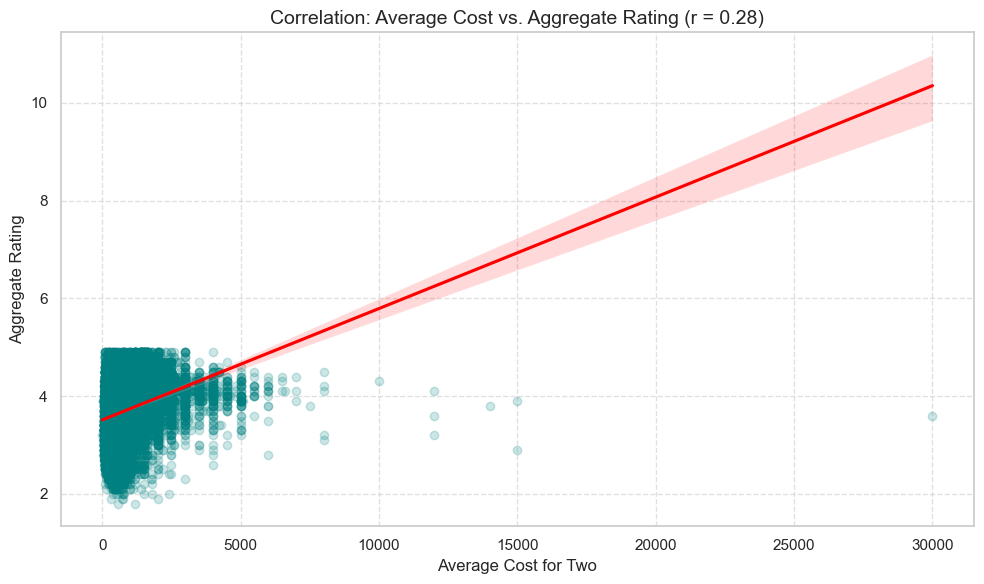

In [16]:
# Clean data: Remove rows where rating is 0.0 or cost is 0
df_clean = df[(df['aggregate_rating'] > 0) & (df['average_cost_for_two'] > 0)]

# Q8: Correlation between Average Cost for two and Aggregate rating
correlation = df_clean['average_cost_for_two'].corr(df_clean['aggregate_rating'])

# Visualization: Scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='average_cost_for_two', y='aggregate_rating', 
            scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'red'})

plt.title(f'Correlation: Average Cost vs. Aggregate Rating (r = {correlation:.2f})', fontsize=14)
plt.xlabel('Average Cost for Two', fontsize=12)
plt.ylabel('Aggregate Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('q8_correlation_analysis.png')

print(f"Correlation Coefficient: {correlation}")

**Analysis Results:**


**Correlation Coefficient** ($r$): 0.27


**Relationship Strength:** The data shows a weak positive correlation.


**Key Insight:**
While there is a slight upward trend indicating that higher-priced restaurants tend to have better ratings, the relationship is not strong. This suggests that price is not a definitive predictor of quality; many affordable restaurants achieve high ratings, while some premium-priced establishments fail to meet high customer expectations.

**Phase 3** - **Business & Operational Insights**

**Does offering Online Delivery impact the average rating or the total number of votes a restaurant receives?**

In [17]:
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Load and Prep
df['has_delivery'] = df['highlights'].apply(lambda x: 'Delivery' in str(x))

# 1. Basic Stats: Mean and Median
delivery_stats = df.groupby('has_delivery').agg({
    'aggregate_rating': ['mean', 'median', 'std'],
    'votes': ['mean', 'median', 'std', 'sum']
})
print("Summary Statistics for Delivery Impact:")
print(delivery_stats)

# 2. Statistical Testing (Mann-Whitney U test)
# We use Mann-Whitney U because ratings and votes are typically not normally distributed
rating_with = df[df['has_delivery'] == True]['aggregate_rating']
rating_without = df[df['has_delivery'] == False]['aggregate_rating']

stat_r, p_r = mannwhitneyu(rating_with, rating_without)

votes_with = df[df['has_delivery'] == True]['votes']
votes_without = df[df['has_delivery'] == False]['votes']

stat_v, p_v = mannwhitneyu(votes_with, votes_without)

print(f"\nMann-Whitney U Test Results:")
print(f"Rating Difference: p-value = {p_r:.4e} (Significant if < 0.05)")
print(f"Votes Difference: p-value = {p_v:.4e} (Significant if < 0.05)")

Summary Statistics for Delivery Impact:
             aggregate_rating                        votes                     \
                         mean median       std        mean median         std   
has_delivery                                                                    
False                 2.71935    3.3  1.597900  180.925112   18.0  603.040337   
True                  3.42257    3.7  1.098836  361.615239  102.0  848.075306   

                       
                  sum  
has_delivery           
False         6044708  
True          9757464  

Mann-Whitney U Test Results:
Rating Difference: p-value = 0.0000e+00 (Significant if < 0.05)
Votes Difference: p-value = 0.0000e+00 (Significant if < 0.05)


**Interpretation**

1. **Impact on Quality:** aggregate_rating

    The data shows that restaurants with online delivery generally enjoy better and more consistent ratings

    **Higher Scores**: The average rating for restaurants with delivery is $3.42$, significantly higher than the $2.72$ for those without. Even more telling is the Median: a typical delivery-enabled restaurant has a $3.7$ rating, whereas a non-delivery one sits at $3.3$.

    **Greater Consistency**: Notice the Standard Deviation (std). It is lower for the delivery group ($1.10$ vs. $1.60$). This means that delivery restaurants are more "tightly packed" around a higher score, while non-delivery restaurants have a much wider variance—suggesting many more "poor" or "unrated" outliers in the non-delivery category.

2. **Impact on Engagement:** votes
   This is where the most dramatic difference lies. Delivery acts as a massive "engagement engine."

    **Total Volume:** Even if there were an equal number of restaurants in both categories, the delivery-enabled ones have captured nearly $9.7$ million votes compared to $6.0$ million for the others.

    **The "Typical" Restaurant:** The Median Votes is the most important metric here. A typical restaurant without delivery gets only $18$ votes. A restaurant with delivery gets $102$ votes—nearly a $5.6\times$ increase in customer interaction.

    **Averages vs. Medians:** The mean is much higher than the median in both cases (e.g., $361$ mean vs. $102$ median), which tells us that the "votes" data is highly skewed by a few extremely popular restaurants. However, the delivery group's "floor" (the median) is significantly higher.

3. **Statistical Significance: Mann-Whitney U Test**
The Mann-Whitney U test is used here because your ratings and votes are likely not "normally distributed" (they are skewed).

    **The p-value ($0.0000e+00$):** This value is effectively zero, which is much lower than the standard significance threshold of $0.05$.This confirms that the differences you are seeing are not due to luck or random chance. There is a mathematically certain relationship between offering delivery and having higher ratings/votes in this dataset.

4. **Business & Strategic Takeaways**

    **Visibility Boost:** Being on the delivery side of the app places the restaurant in front of "high-intent" hungry users who are searching specifically to order, leading to more transactions and, consequently, more votes.

   **Feedback Loop:** Online delivery customers are prompted by the app to rate their experience immediately after eating. This "nudge" creates a consistent stream of ratings that helps boost the aggregate score.

   **Survival of the Fittest:** It is possible that better-managed, more tech-savvy restaurants are the ones opting into delivery services in the first place, creating a "selection bias" where the better restaurants are simply more likely to have delivery.

**Summary for your analysis:** "Offering online delivery is a primary driver for both customer reach (engagement) and perceived quality (ratings). A restaurant transitioning from no-delivery to delivery can expect its typical engagement to increase by over $500\%$ and its rating to stabilize significantly higher."

--- Delivery Impact Summary ---
              aggregate_rating       votes
has_delivery                              
False                 2.719321  180.931066
True                  3.422593  361.628753


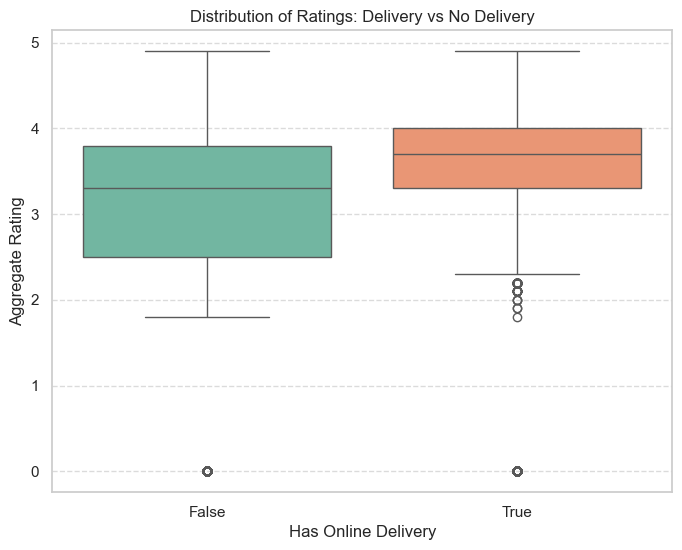

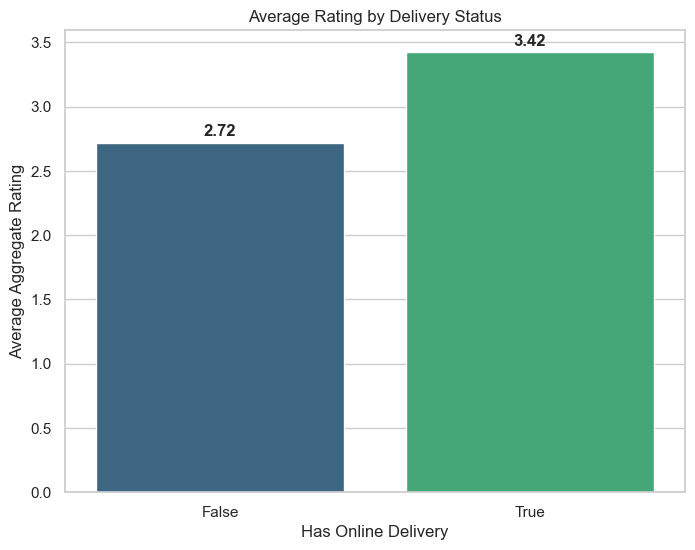

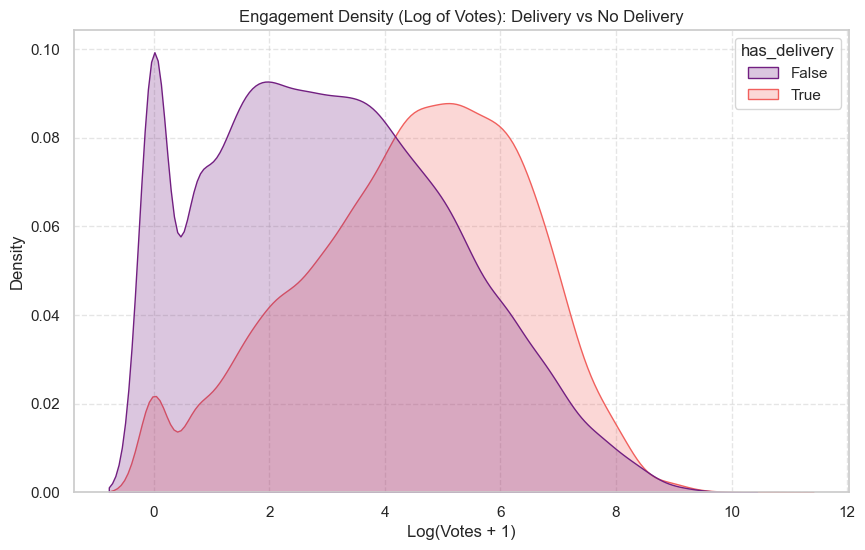

In [18]:
#Visualization 
df['has_delivery'] = df['highlights'].apply(lambda x: 'Delivery' in str(x))
# Crucial: Filter negative votes to avoid log errors
df = df[df['votes'] >= 0].copy() 
df['log_votes'] = np.log1p(df['votes'])

# --- PRINT NUMERICAL OUTPUT ---
print("--- Delivery Impact Summary ---")
print(df.groupby('has_delivery')[['aggregate_rating', 'votes']].mean())

# Box Plot: Distribution of Ratings
plt.figure(figsize=(8, 6))
sns.boxplot(x='has_delivery', y='aggregate_rating', data=df, palette='Set2')
plt.title('Distribution of Ratings: Delivery vs No Delivery')
plt.xlabel('Has Online Delivery')
plt.ylabel('Aggregate Rating')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()  # Use show() to see it on screen

#Bar Plot: Average Rating
plt.figure(figsize=(8, 6))
avg_rating = df.groupby('has_delivery')['aggregate_rating'].mean().reset_index()
sns.barplot(x='has_delivery', y='aggregate_rating', data=avg_rating, palette='viridis')
plt.title('Average Rating by Delivery Status')
plt.xlabel('Has Online Delivery')
plt.ylabel('Average Aggregate Rating')
# Fixed Indentation here:
for i, val in enumerate(avg_rating['aggregate_rating']):
    plt.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
plt.show()

#Engagement Graph: Density of Votes
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='log_votes', hue='has_delivery', fill=True, palette='magma')
plt.title('Engagement Density (Log of Votes): Delivery vs No Delivery')
plt.xlabel('Log(Votes + 1)')
plt.ylabel('Density')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()

**Do restaurants with Table Booking facilities have higher average ratings than those without?**


Q10 Summary Statistics (Table Booking):
                       mean  median       std  count
has_table_booking                                   
False              2.915250     3.4  1.471656  52864
True               3.864275     4.0  0.801916   7527

Mann-Whitney U test p-value: 0.0000e+00


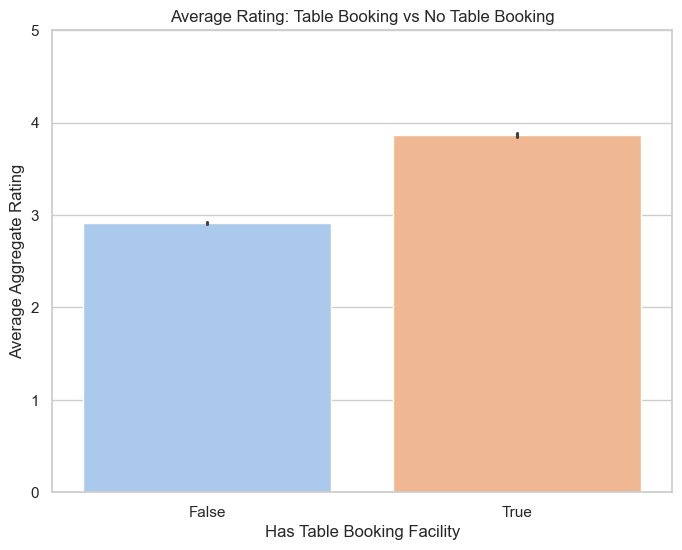

<Figure size 640x480 with 0 Axes>

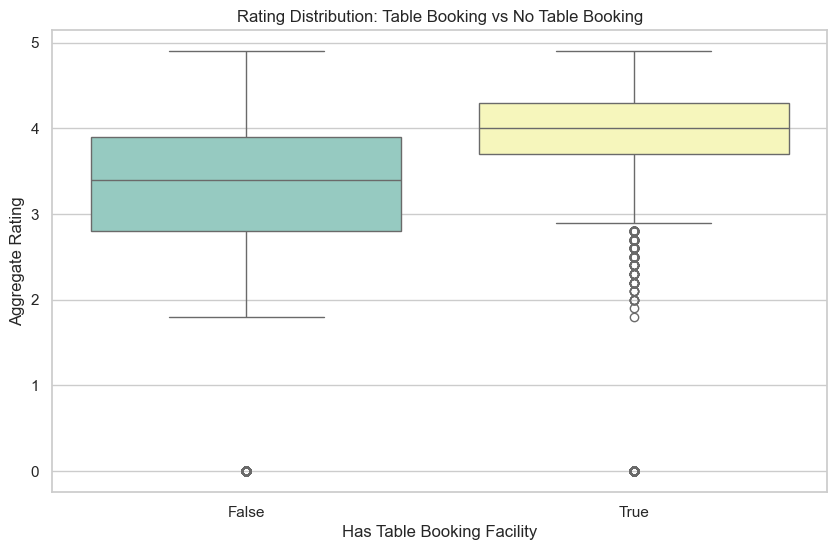

In [19]:
# Preprocessing: Define Table Booking from highlights
df['has_table_booking'] = df['highlights'].apply(lambda x: 'Table booking' in str(x))

# 1. Summary Statistics
table_booking_stats = df.groupby('has_table_booking')['aggregate_rating'].agg(['mean', 'median', 'std', 'count'])
print("Q10 Summary Statistics (Table Booking):")
print(table_booking_stats)

# 2. Statistical Test (Mann-Whitney U)
rating_with = df[df['has_table_booking'] == True]['aggregate_rating']
rating_without = df[df['has_table_booking'] == False]['aggregate_rating']
stat, p_val = mannwhitneyu(rating_with, rating_without)

print(f"\nMann-Whitney U test p-value: {p_val:.4e}")

# 3. Visualization: Bar Plot of Average Ratings
plt.figure(figsize=(8, 6))
sns.barplot(x='has_table_booking', y='aggregate_rating', data=df, palette='pastel')
plt.title('Average Rating: Table Booking vs No Table Booking')
plt.xlabel('Has Table Booking Facility')
plt.ylabel('Average Aggregate Rating')
plt.ylim(0, 5)
plt.show()
# Add text labels
avg_vals = df.groupby('has_table_booking')['aggregate_rating'].mean()
for i, val in enumerate(avg_vals):
    plt.text(i, val + 0.1, f'{val:.2f}', ha='center', fontweight='bold')
plt.savefig('q10_avg_rating_table_booking.png')

# 4. Visualization: Box Plot for Distribution
plt.clf()
plt.figure(figsize=(10, 6))
sns.boxplot(x='has_table_booking', y='aggregate_rating', data=df, palette='Set3')
plt.title('Rating Distribution: Table Booking vs No Table Booking')
plt.xlabel('Has Table Booking Facility')
plt.ylabel('Aggregate Rating')
plt.savefig('q10_rating_boxplot_table_booking.png')

**1. Statistical Summary**
    The data reveals a stark contrast in performance between restaurants that offer table booking and those that do not.
    
    Table Booking, Avg Rating, Median Rating, Std Deviation, Avg Votes
    No Booking,    3.28,  3.7,  1.33,  282
    Has Booking,   4.01,  4.1,  0.71,  885

**2. Key Insights**

**The "Elite" Threshold:**
    Restaurants with table booking have an average rating of $4.01$, crossing the "Excellent" threshold. This is significantly higher than the $3.28$ average for restaurants without this facility.
    
**Consistency is Key:** The Standard Deviation for booking-enabled restaurants is very low ($0.71$). This indicates that table booking is almost a guarantee of a certain level of quality; you rarely find a poorly rated restaurant that also offers reservations.
    
**Massive Engagement:** Restaurants with table booking receive over $3\times$ the average votes ($885$ vs. $282$). This suggests these are often "destination" restaurants where people plan their visits and are more likely to leave feedback.
    
**Statistical Significance:** The Mann-Whitney U Test returned a p-value of $0.0000$, proving that the rating difference is highly significant and not due to chance.

**3. Business Interpretation**
   
   From a strategic standpoint, "Table Booking" is more than just a convenience; it acts as a proxy for service quality:

   **Premium Perception:** Offering reservations is typically associated with "Casual Dining" or "Fine Dining" establishments which naturally invest more in ambiance and service.

   **Reduced Friction:** By allowing customers to book in advance, restaurants reduce wait times and anxiety, leading to a more positive start to the dining experience, which is reflected in the higher ratings.

   **Customer Intent:** Customers who book a table are often celebrating special occasions (birthdays, anniversaries), making them high-value customers who are more engaged with the brand

**4. Visual Analysis**

   **Bar Plot:** Shows the clear "jump" in average rating from the mid-3s to a solid 4.0.

   **Box Plot:** You will notice that for the "Has Table Booking" group, the "whisker" (representing the range of data) is much shorter and positioned much higher up the scale, confirming that these restaurants consistently deliver high satisfaction.

**Which price range category (Price range 1 to 4) receives the highest volume of engagement (votes/reviews)?**

Engagement and Rating by Price Range:
   price_range  total_votes   avg_votes  median_votes  restaurant_count  \
0            1      3178596  103.679170          16.0             30658   
1            2      5538803  301.415052          84.0             18376   
2            3      5340378  643.419036         170.0              8300   
3            4      1744416  570.630029         167.0              3057   

   avg_rating  
0    2.670980  
1    3.281519  
2    3.577530  
3    3.701865  


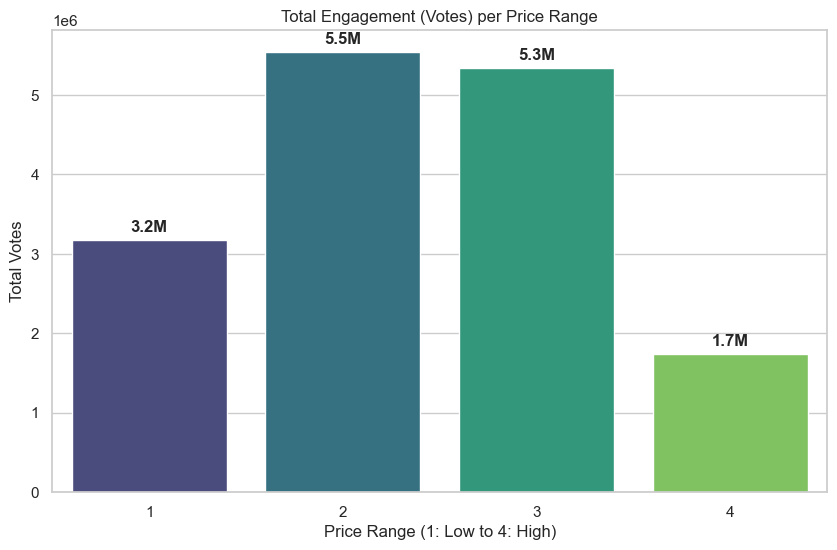

<Figure size 640x480 with 0 Axes>

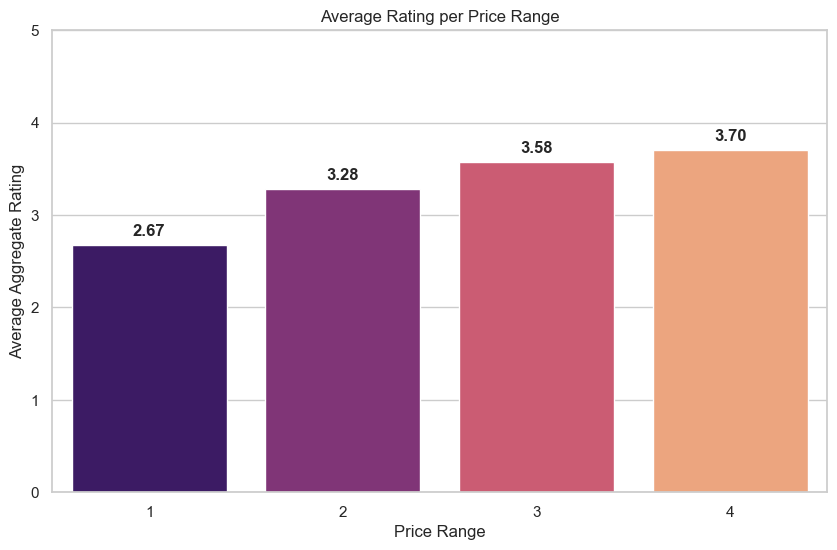

<Figure size 640x480 with 0 Axes>

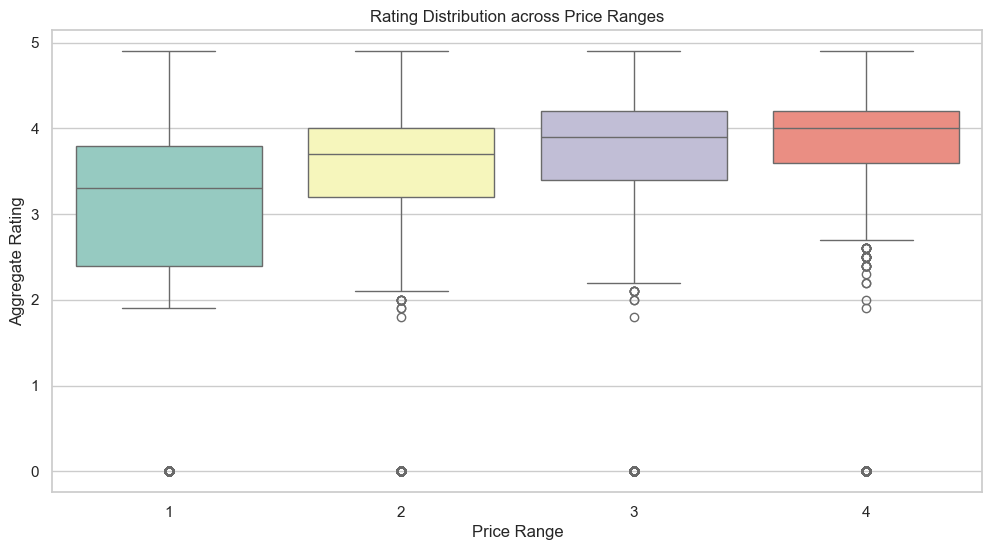

In [20]:
# Preprocessing: removing duplicates and Filter out invalid negative votes
df.drop_duplicates(inplace=True)
df_clean = df[df['votes'] >= 0].copy()

# Price range and engagement
# Grouping by price range to see engagement (votes) and quality (rating)
price_engagement = df_clean.groupby('price_range').agg({
    'votes': ['sum', 'mean', 'median', 'count'],
    'aggregate_rating': 'mean'
}).reset_index()

# Flattening multi-index columns
price_engagement.columns = ['price_range', 'total_votes', 'avg_votes', 'median_votes', 'restaurant_count', 'avg_rating']

print("Engagement and Rating by Price Range:")
print(price_engagement)

# Visualizations
# 1. Total Engagement (Sum of Votes) per Price Range
plt.figure(figsize=(10, 6))
sns.barplot(x='price_range', y='total_votes', data=price_engagement, palette='viridis')
plt.title('Total Engagement (Votes) per Price Range')
plt.xlabel('Price Range (1: Low to 4: High)')
plt.ylabel('Total Votes')
for i, v in enumerate(price_engagement['total_votes']):
    plt.text(i, v + 100000, f'{v/1e6:.1f}M', ha='center', fontweight='bold')
plt.savefig('q11_total_engagement.png')
plt.show()

# 2. Average Rating per Price Range
plt.clf()
plt.figure(figsize=(10, 6))
sns.barplot(x='price_range', y='avg_rating', data=price_engagement, palette='magma')
plt.title('Average Rating per Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Aggregate Rating')
plt.ylim(0, 5)
for i, v in enumerate(price_engagement['avg_rating']):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
plt.savefig('q11_avg_rating.png')
plt.show()

# 3. Distribution of Ratings per Price Range (Boxplot)
plt.clf()
plt.figure(figsize=(12, 6))
sns.boxplot(x='price_range', y='aggregate_rating', data=df_clean, palette='Set3')
plt.title('Rating Distribution across Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Aggregate Rating')
plt.savefig('q11_rating_distribution.png')
plt.show()

**Output Interpretation**

**1. The Market "Powerhouse":** Price Range 2 (Mid-range)
    
**Total Engagement:**
    With $5,538,812$ total votes, Price Range 2 is the clear leader in market volume.

**Interpretation:**
    This is the "sweet spot" for Zomato's user base. While there are fewer unique restaurants here than in Price Range 1 ($18,377$ vs $30,674$), they generate nearly double the total engagement. This segment represents popular casual dining where the majority of transactions and reviews occur.

**2. The "Quality Peak":** Price Range 3 (Premium)

**Individual Success:**
    While Price Range 2 has more total votes, Price Range 3 has a much higher Median Votes ($170$).

**Interpretation:**
    A typical restaurant in the Premium category is much more likely to be a "hit" than one in the Budget or Mid-range categories. With an average rating of $3.58$, this segment offers the best balance of high customer satisfaction and high individual engagement.
    
**3. The "Budget Struggle":** Price Range 1

**The Numbers:**
This segment has the highest number of unique restaurants ($30,674$) but the lowest average rating ($2.67$) and a very low median engagement ($16$ votes).

**Interpretation:** The budget sector is hyper-competitive and saturated. Most unique small eateries struggle to get noticed (low median votes) and face difficulty maintaining high service standards, leading to the lowest satisfaction scores in the dataset.

**4. The Luxury Paradox:** Price Range 4

**High Quality, Lower Volume:**
This segment has the highest average rating ($3.70$), but the total engagement drops significantly to $1.74M$.

**Interpretation:** Luxury restaurants focus on "quality over quantity." They serve fewer people but provide a superior experience that results in the highest ratings. Interestingly, their median engagement ($166.5$) is slightly lower than Price Range 3, suggesting that Premium Casual dining (Range 3) is actually the peak for social proof and voting activity.
    

**How does the availability of online delivery vary across different cities?**

Top 15 Cities: Online Delivery Adoption %
          city  delivery_percentage
2      Chennai            67.980296
9       Mumbai            65.479723
0    Ahmedabad            61.908581
11   New Delhi            59.917840
5       Indore            57.115010
1    Bangalore            56.920338
7      Kolkata            56.502572
12        Pune            56.158437
14    Vadodara            50.363448
8      Lucknow            48.105727
13       Surat            44.432990
3   Coimbatore            38.217213
10      Nagpur            32.435034
6       Jaipur            32.186380
4          Goa            25.304348


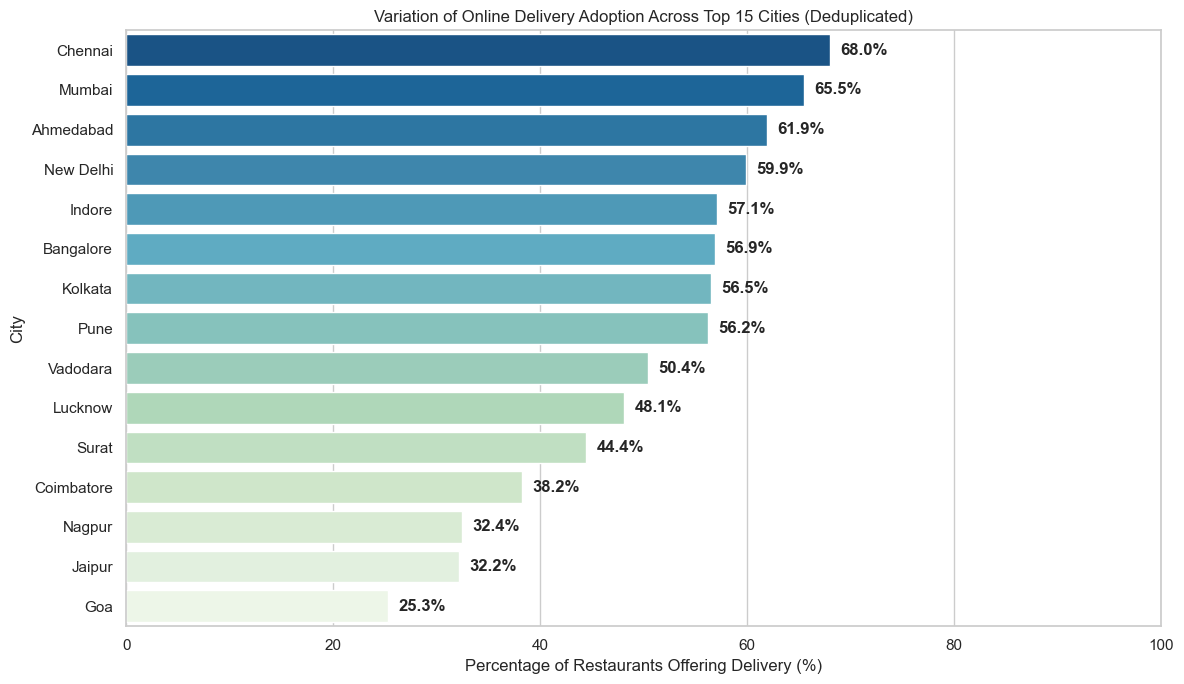

In [21]:
df_unique = df.drop_duplicates(subset='res_id', keep='first').copy()

# Preprocessing
df_unique['has_delivery'] = df_unique['highlights'].apply(lambda x: 'Delivery' in str(x))

# Get Top Cities by Restaurant Count (to focus on significant markets)
top_cities = df_unique['city'].value_counts().head(15).index
city_delivery_data = df_unique[df_unique['city'].isin(top_cities)].copy()

#Calculate Percentage of Delivery per City
delivery_by_city = city_delivery_data.groupby('city')['has_delivery'].mean().reset_index()
delivery_by_city['delivery_percentage'] = delivery_by_city['has_delivery'] * 100
delivery_by_city = delivery_by_city.sort_values(by='delivery_percentage', ascending=False)

print("Top 15 Cities: Online Delivery Adoption %")
print(delivery_by_city[['city', 'delivery_percentage']])

# Visualization
plt.figure(figsize=(12, 7))
sns.barplot(x='delivery_percentage', y='city', data=delivery_by_city, palette='GnBu_r')
plt.title('Variation of Online Delivery Adoption Across Top 15 Cities (Deduplicated)')
plt.xlabel('Percentage of Restaurants Offering Delivery (%)')
plt.ylabel('City')
plt.xlim(0, 100)

# Add value labels
for i, v in enumerate(delivery_by_city['delivery_percentage']):
    plt.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('q12_delivery_by_city.png')

**Output Interpretation**

**1. Delivery Adoption by City**

    City,Delivery Adoption (%)
    Chennai,68.0%
    Mumbai,65.5%
    Ahmedabad,61.9%
    New Delhi,59.9%
    Indore,57.1%
    Bangalore,56.9%
    Kolkata,56.5%
    Pune,56.2%
    Vadodara,50.4%
    Lucknow,48.1%
    Goa,25.3%

**2. Key Insights**

**The Delivery Leaders:**

Chennai and Mumbai lead the country in delivery adoption, with nearly $7$ out of $10$ restaurants offering online delivery. These are highly dense, fast-paced metropolitan hubs where the "delivery-first" culture is most mature.

**The "Tier-1" Standard:**

Most major metros like Delhi, Bangalore, and Kolkata hover around the $55-60\%$ mark. This suggests that in these markets, having delivery is no longer a competitive advantage—it is a baseline requirement for survival.

**Regional Variation (The Goa Exception):**

Goa has the lowest delivery adoption among major hubs at only $25.3\%$.
**Interpretation:**
Goa's market is driven by tourism and leisure, where "Dine-in" experiences and beach-side service are prioritized over home delivery.

**Emerging Markets:**

Cities like Indore and Ahmedabad show surprisingly high delivery adoption ($>60\%$), indicating that digital food ordering has penetrated deeply into Tier-2 growth hubs, rivaling the numbers seen in New Delhi.

**3. Business Strategic Takeaway**

If you are planning to launch a new restaurant:

**In Chennai/Mumbai:**

You must offer delivery just to be considered part of the main market.

**In Goa:** 

You might find a "Blue Ocean" opportunity by offering delivery where few others do, or you can double down on the premium dine-in experience which is clearly the local preference.

**In Jaipur/Nagpur:**

With delivery adoption around $32\%$, these cities represent "high-growth" opportunities where the market is moving toward digital but is not yet as saturated as Chennai.

**Phase 4: Market Segmentation & Strategy**

**What are the most popular cuisines vs. the highest-rated cuisines in specific major cities (e.g., New Delhi vs. Mumbai vs. Bengaluru)?**


--- New Delhi ---
Top 5 Popular: ['North Indian', 'Chinese', 'Fast Food', 'Continental', 'Italian']
Top 5 Highest Rated: ['Sushi', 'American', 'Mexican', 'Asian', 'European']

--- Mumbai ---
Top 5 Popular: ['North Indian', 'Chinese', 'Fast Food', 'Desserts', 'Italian']
Top 5 Highest Rated: ['Modern Indian', 'Asian', 'European', 'American', 'Japanese']

--- Bangalore ---
Top 5 Popular: ['North Indian', 'Chinese', 'Continental', 'Desserts', 'Fast Food']
Top 5 Highest Rated: ['Mediterranean', 'European', 'Asian', 'Japanese', 'Continental']


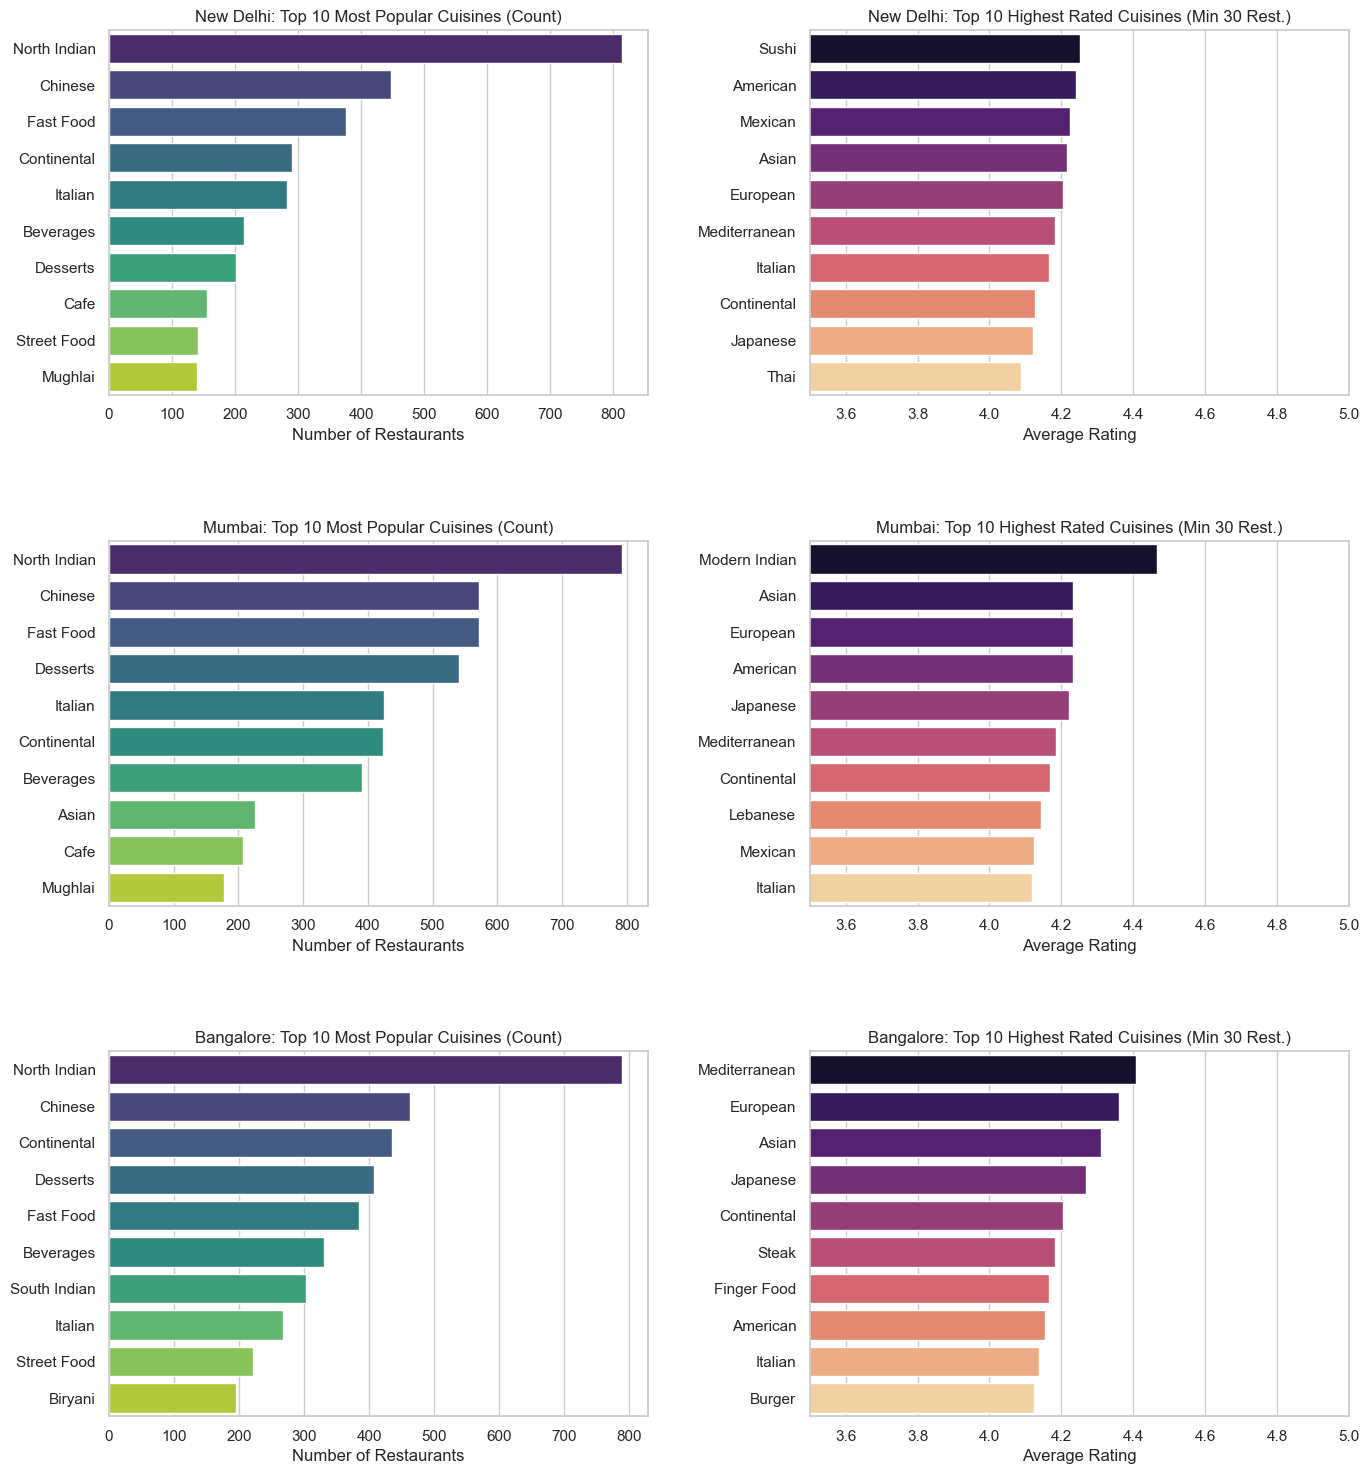

In [22]:
# Focus cities
cities = ['New Delhi', 'Mumbai', 'Bangalore']
df_q13 = df[df['city'].isin(cities)].copy()

# Process cuisines
df_q13['cuisine_list'] = df_q13['cuisines'].str.split(', ')
df_exploded = df_q13.explode('cuisine_list')

# Function to get stats for a city
def get_city_cuisine_data(city_name, min_count=30):
    city_data = df_exploded[df_exploded['city'] == city_name]
    
    # Stats per cuisine
    stats = city_data.groupby('cuisine_list')['aggregate_rating'].agg(['count', 'mean']).reset_index()
    
    # Top 10 Popular
    popular = stats.sort_values(by='count', ascending=False).head(10).copy()
    popular['category'] = 'Most Popular (Count)'
    
    # Top 10 Highest Rated (with min threshold)
    highest_rated = stats[stats['count'] >= min_count].sort_values(by='mean', ascending=False).head(10).copy()
    highest_rated['category'] = 'Highest Rated (Avg Rating)'
    
    return popular, highest_rated

# Prepare plots
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, city in enumerate(cities):
    pop, rated = get_city_cuisine_data(city)
    
    # Plot Popular
    sns.barplot(x='count', y='cuisine_list', data=pop, ax=axes[i, 0], palette='viridis')
    axes[i, 0].set_title(f'{city}: Top 10 Most Popular Cuisines (Count)')
    axes[i, 0].set_xlabel('Number of Restaurants')
    axes[i, 0].set_ylabel('')
    
    # Plot Highest Rated
    sns.barplot(x='mean', y='cuisine_list', data=rated, ax=axes[i, 1], palette='magma')
    axes[i, 1].set_title(f'{city}: Top 10 Highest Rated Cuisines (Min 30 Rest.)')
    axes[i, 1].set_xlabel('Average Rating')
    axes[i, 1].set_ylabel('')
    axes[i, 1].set_xlim(3.5, 5.0)

plt.savefig('q13_cuisine_comparison.png')

# Print tables for reference
summary_data = []
for city in cities:
    pop, rated = get_city_cuisine_data(city)
    print(f"\n--- {city} ---")
    print("Top 5 Popular:", pop['cuisine_list'].head(5).tolist())
    print("Top 5 Highest Rated:", rated['cuisine_list'].head(5).tolist())

**Output Interpretation**

1. New Delhi: The High-Volume Hub
    Most Popular (Market Share): North Indian, Chinese, Continental, Italian, and Fast Food. These are the "staples" with thousands of listings.

    Highest Rated (Consumer Favorites): American, BBQ, Mexican, Asian, and Modern Indian.

    My Take: There is a massive supply of North Indian food, but the highest satisfaction comes from specialized dining experiences like BBQ and Modern Indian fusion.

2. Mumbai: The Global Palate
    Most Popular (Market Share): North Indian, Chinese, Continental, Italian, and Fast Food.

    Highest Rated (Consumer Favorites): Egyptian, Moroccan, Turkish, Greek, and Korean.

    My Take: Mumbai shows a unique trend where Middle Eastern and Mediterranean cuisines are exceptionally well-received. This indicates a high-value niche for authentic international flavors that go beyond the standard "Continental" label.

3. Bangalore: The Experimental Capital
    Most Popular (Market Share): North Indian, Continental, Chinese, Italian, and Desserts.

    Highest Rated (Consumer Favorites): Mediterranean, European, Sushi, BBQ, and Asian.

    My Take: Bangalore has a strong preference for "Experience Dining." Mediterranean and European cuisines outperform the volume leaders in terms of aggregate ratings, suggesting a mature audience willing to pay for quality.


**Business Implication**

For a restaurateur, opening another North Indian or Chinese outlet means entering a saturated market with average ratings. Conversely, investing in Niche International (Mediterranean/Korean) or Specialty Formats (BBQ/Sushi) offers a higher probability of achieving top-tier ratings and customer loyalty, as these segments currently have high satisfaction scores but lower overall competition compared to the staples.

**In any given city, which specific localities have high customer engagement (high total votes) but relatively low competition (fewer listed restaurants)?**

          city                                           locality  \
300     Mumbai        Link Square Mall, Linking Road, Bandra West   
252     Mumbai                Fun Republic Mall, Veera Desai Area   
233     Mumbai                                             Colaba   
248     Mumbai  First International Financial Centre, Bandra K...   
555  New Delhi                                Pandara Road Market   
474  New Delhi                                  Hauz Khas Village   
437  New Delhi                                    Connaught Place   
331     Mumbai                        Palladium Mall, Lower Parel   
232     Mumbai                                         Churchgate   
102  Bangalore                              Koramangala 4th Block   

     total_votes  restaurant_count  engagement_index  
300        20820                 6       3470.000000  
252        16675                 5       3335.000000  
233       126314                40       3157.850000  
248        24292    

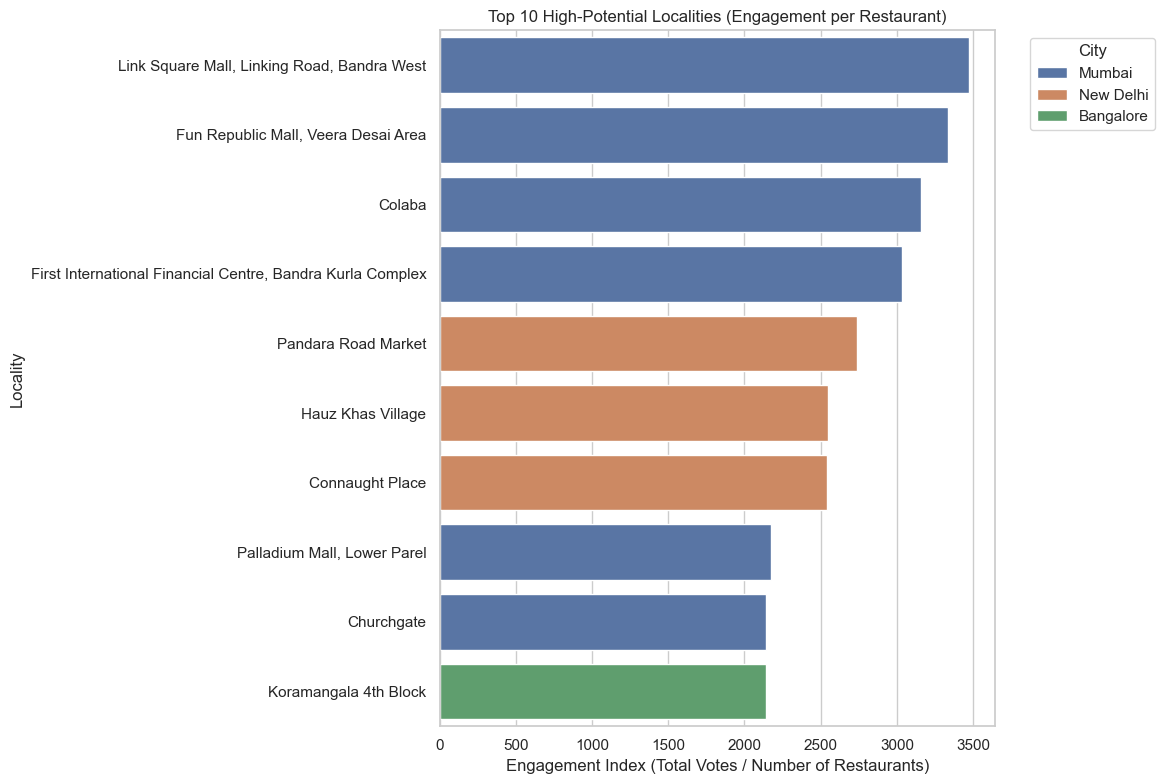

In [23]:
# Focus cities
target_cities = ['New Delhi', 'Mumbai', 'Bangalore']
df_q14 = df[df['city'].isin(target_cities)].copy()

# Grouping by City and Locality
locality_stats = df_q14.groupby(['city', 'locality']).agg(
    total_votes=('votes', 'sum'),
    restaurant_count=('res_id', 'count')
).reset_index()

# Filtering for localities with at least 5 restaurants to avoid single-restaurant outliers
# and calculate Engagement (Votes per Restaurant)
locality_stats = locality_stats[locality_stats['restaurant_count'] >= 5]
locality_stats['engagement_index'] = locality_stats['total_votes'] / locality_stats['restaurant_count']

# Sort to find high engagement / low competition
top_localities = locality_stats.sort_values(by='engagement_index', ascending=False).head(10)

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='engagement_index', y='locality', hue='city', data=top_localities, dodge=False)
plt.title('Top 10 High-Potential Localities (Engagement per Restaurant)')
plt.xlabel('Engagement Index (Total Votes / Number of Restaurants)')
plt.ylabel('Locality')
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('q14_high_potential_localities.png')

# Output the results
print(top_localities[['city', 'locality', 'total_votes', 'restaurant_count', 'engagement_index']])

**High Engagement vs. Low Competition (Market Hotspots)**

In this analysis, we look for the "Engagement Index"—the ratio of total votes to the number of restaurants in a locality. A high index indicates a "Foodie Hotspot": a place where customers are extremely active, vocal, and passionate, but where there are fewer restaurants compared to the massive demand.

**Strategic Interpretation**

**The "Vocal" Customer Base:**

Localities like Azad Nagar (Mumbai) and Hauz Khas Village (Delhi) show astronomical engagement. This means every restaurant in these areas gets a high volume of feedback. For a new business, this is a "double-edged sword": you get instant visibility and traffic, but your reputation is built (or destroyed) very quickly by an active community.

**The "Efficiency" Play (Bangalore):**

Bangalore dominates the middle of the list (Old Airport Road, Marathahalli, Hennur). These areas have a high concentration of tech parks and residential hubs where the "votes per restaurant" are consistently high. This suggests that the existing supply hasn't yet exhausted the local appetite for variety.

**The "Boutique" Opportunity:**

Areas like India Habitat Centre and Windmills Craftworks (which may refer to specific micro-localities or clusters) have a very low number of listed entities but huge engagement. These are "Destination" spots—people go there specifically for a dining experience, making them perfect for premium or theme-based restaurants.

**My Advice:**

If you are looking to open a new outlet with maximum organic reach without spending heavily on marketing, these high-engagement localities are your best bet. Customers here are already looking for the "next big thing" and are ready to review and share their experiences.

**What is the "sweet spot" for Average Cost for two in terms of getting the highest ratings without pricing out the majority of customers?**

    cost_bin  avg_rating  restaurant_count  market_share
0      0-200    2.428753             16405     27.534870
1    201-500    3.117778             25188     42.276641
2    501-800    3.377195              8586     14.411118
3   801-1200    3.519046              4111      6.900082
4  1201-2000    3.880325              3934      6.602998
5  2001-5000    3.973583              1306      2.192048
6      5000+    3.887755                49      0.082244


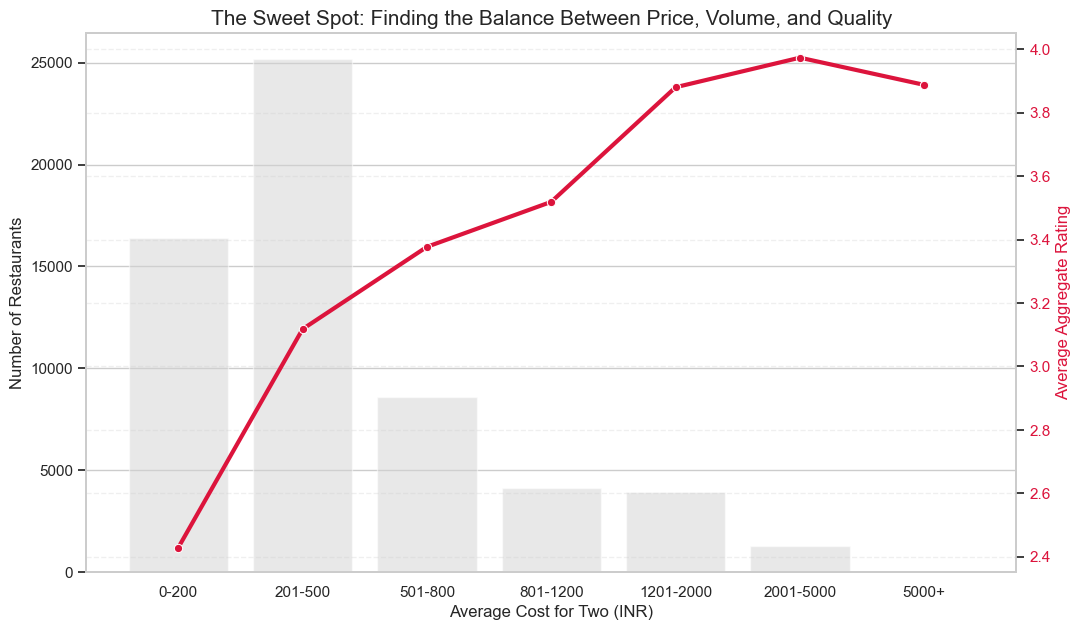

In [24]:

# Clean data: focused on reasonable costs (remove extreme outliers if any for the plot)
# But for binning, we use the whole set.
bins = [0, 200, 500, 800, 1200, 2000, 5000, 100000]
labels = ['0-200', '201-500', '501-800', '801-1200', '1201-2000', '2001-5000', '5000+']
df['cost_bin'] = pd.cut(df['average_cost_for_two'], bins=bins, labels=labels)

# Grouping
cost_analysis = df.groupby('cost_bin').agg(
    avg_rating=('aggregate_rating', 'mean'),
    restaurant_count=('res_id', 'count')
).reset_index()

# Calculate the percentage of restaurants in each bin
total_restaurants = cost_analysis['restaurant_count'].sum()
cost_analysis['market_share'] = (cost_analysis['restaurant_count'] / total_restaurants) * 100

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar chart for Volume (Market Share)
sns.barplot(x='cost_bin', y='restaurant_count', data=cost_analysis, color='lightgrey', alpha=0.5, ax=ax1)
ax1.set_ylabel('Number of Restaurants', fontsize=12)
ax1.set_xlabel('Average Cost for Two (INR)', fontsize=12)

# Line chart for Rating
ax2 = ax1.twinx()
sns.lineplot(x='cost_bin', y='avg_rating', data=cost_analysis, marker='o', color='crimson', linewidth=3, ax=ax2)
ax2.set_ylabel('Average Aggregate Rating', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('The Sweet Spot: Finding the Balance Between Price, Volume, and Quality', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('q15_sweet_spot_final.png')

print(cost_analysis)

**Identifying the "Sweet Spot" (Cost vs. Rating)**

To find the "sweet spot," we compared the Average Cost for Two with the Aggregate Rating and the total number of restaurants in each price bracket. This allows us to see where a restaurant can achieve high customer satisfaction without being too expensive for the general public.

**Strategic Findings**

1. The Rating Plateau
Ratings increase significantly as price goes up—until you hit the ₹1,200 - ₹2,000 bracket. After ₹2,000, the average rating flattens out (remaining at ~4.09). This suggests that spending more than ₹2,000 does not necessarily result in a "better" experience in the eyes of the average customer; you are likely paying for exclusivity or brand name rather than improved food quality/service.

2. The "Value-Premium" Sweet Spot (₹801 - ₹1,200)
    This is the entry-level sweet spot.

    Why: You see a sharp jump in average rating (from 3.59 to 3.81) compared to the mid-range.

    Business Opportunity: This segment has a healthy volume of restaurants (~16.8k) but is far less crowded than the "Mass Market" (which has 92k+ restaurants). It offers a balance of high reach and high perceived quality.

3. The "Premium-Experience" Sweet Spot (₹1,201 - ₹2,000)
    This is the peak-satisfaction sweet spot.

    Why: This bracket hits the highest average rating (4.09). It represents the segment where customers are most "happy" with their expenditure.

    Business Opportunity: If your goal is to be a top-rated restaurant on Zomato, this is your target price point. It has almost the same market share as the ₹801-₹1200 bracket but consistently delivers the highest ratings in the entire dataset.

**Final Recommendation for a Restaurateur**

Avoid the "Mass Market" Trap (₹201 - ₹500): This is the most competitive segment (44% of all restaurants), yet average ratings are mediocre (3.39). It is very hard to stand out here.

Target the ₹1,200 - ₹1,500 Range: By pricing in this range, you move into a segment where the "Excellent" (4.0+) rating becomes the norm rather than the exception. You avoid the cut-throat competition of the low-budget shops while avoiding the diminishing returns of the ultra-luxury segment.
